# 06 - scDRS: per-nucleus polygenic risk

scDRS turns the MAGMA gene-level Z scores into a per-nucleus disease-relevance score, comparing
each cell's weighted expression of the top risk genes against 1,000 control gene sets matched on
mean expression and variance.

**Correction over the earlier run.** scDRS was previously scored on the z-scaled matrix that
notebook 02 used to save. scDRS's mean/variance binning and its variance-weighting assume
size-factor-normalised, log1p expression, so scaled input violates its model. This notebook
scores `interim/adata_clustered.h5ad`, whose `X` is log1p(CP10K) - the inputs scDRS expects.

Outputs: `results/figures/06_scdrs_overview.png`, plus `interim/scdrs_cell_scores.tsv` and
`interim/scdrs_full_score.tsv` (with all 1,000 control scores) for notebook 07.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from adpipe import *

import numpy as np
import pandas as pd
import scanpy as sc
import scdrs
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

N_TOP_GENES, N_CTRL = 1000, 1000
print("scdrs", scdrs.__version__)

scdrs 1.0.2


In [2]:
magma = pd.read_csv(TABLES / "04_magma_genes.tsv", sep="\t")

# scDRS keys on gene symbols; keep the most significant row per symbol
gs = (magma.dropna(subset=["SYMBOL"])
           .sort_values("P")
           .drop_duplicates(subset="SYMBOL")[["SYMBOL", "ZSTAT"]]
           .rename(columns={"SYMBOL": "GENE", "ZSTAT": "AD"}))
print(f"genes with a symbol and a Z score: {len(gs):,}")
gs.head()

genes with a symbol and a Z score: 18,626


,GENE,AD
16983,APOC1,11.0110
16985,APOC2,8.8056
3163,INPP5D,8.5081
16977,BCL3,8.0194
10548,MS4A6A,7.8970


In [3]:
adata = sc.read_h5ad(INTERIM / "adata_clustered.h5ad")
print("X is log1p(CP10K):  min", round(float(adata.X.min()), 3),
      " max", round(float(adata.X.max()), 3))

gs_in_data = gs[gs["GENE"].isin(adata.var_names)]
top = gs_in_data.sort_values("AD", ascending=False).head(N_TOP_GENES)
print(f"risk genes present in the expression matrix: {len(gs_in_data):,}")
print(f"using the top {len(top):,} by MAGMA Z (Z range {top['AD'].min():.2f} - {top['AD'].max():.2f})")
top.head(10)

X is log1p(CP10K):  min 0.0  max 8.502
risk genes present in the expression matrix: 9,349
using the top 1,000 by MAGMA Z (Z range 2.01 - 11.01)


,GENE,AD
16983,APOC1,11.0110
3163,INPP5D,8.5081
10548,MS4A6A,7.8970
2653,BIN1,7.6477
13099,SLC24A4,7.5502
16986,CLPTM1,7.4895
16981,TOMM40,7.4684
16982,APOE,7.3818
9639,TSPAN14,7.3021
16079,POLR2E,7.1554


In [4]:
scdrs.preprocess(adata, n_mean_bin=20, n_var_bin=20)

full_score = scdrs.score_cell(
    data=adata,
    gene_list=top["GENE"].tolist(),
    gene_weight=top["AD"].tolist(),
    ctrl_match_key="mean_var",
    n_ctrl=N_CTRL,
    weight_opt="vs",
    return_ctrl_raw_score=False,
    return_ctrl_norm_score=True,
)
print("full score matrix:", full_score.shape)
full_score.iloc[:5, :6].round(4)

Computing control scores:   0%|          | 0/1000 [00:00<?, ?it/s]

Computing control scores:   0%|          | 2/1000 [00:00<01:17, 12.92it/s]

Computing control scores:   0%|          | 4/1000 [00:00<01:03, 15.77it/s]

Computing control scores:   1%|          | 6/1000 [00:00<01:01, 16.14it/s]

Computing control scores:   1%|          | 8/1000 [00:00<01:00, 16.38it/s]

...

Computing control scores: 100%|█████████▉| 996/1000 [00:47<00:00, 20.08it/s]

Computing control scores: 100%|█████████▉| 999/1000 [00:47<00:00, 19.47it/s]

Computing control scores: 100%|██████████| 1000/1000 [00:47<00:00, 21.03it/s]

full score matrix: (13214, 1006)


,raw_score,norm_score,mc_pval,pval,nlog10_pval,zscore
AAACCTGGTAGAAAGG_AD5_AD6,0.1221,1.4227,0.0789,0.0813,1.0901,1.3966
AAACCTGGTAGCGATG_AD5_AD6,0.1018,0.6914,0.2428,0.2404,0.6192,0.7052
AAACCTGTCAGTCAGT_AD5_AD6,0.0900,-1.9907,0.9740,0.9816,0.0080,-2.0891
AAACCTGTCCAAACAC_AD5_AD6,0.0758,-1.0725,0.8611,0.8593,0.0658,-1.0773
AAACCTGTCCAGTATG_AD5_AD6,0.0618,-1.4515,0.9371,0.9314,0.0309,-1.4864


In [5]:
full_score.to_csv(INTERIM / "scdrs_full_score.tsv", sep="\t")
print("interim -> interim/scdrs_full_score.tsv "
      f"({(INTERIM / 'scdrs_full_score.tsv').stat().st_size / 1e6:.0f} MB, "
      "carries the 1,000 control scores for notebook 07)")

slim = full_score[["raw_score", "norm_score", "mc_pval", "pval", "zscore"]].copy()
slim["fdr"] = multipletests(slim["pval"], method="fdr_bh")[1]
slim.to_csv(INTERIM / "scdrs_cell_scores.tsv", sep="\t")
print("interim -> interim/scdrs_cell_scores.tsv (carried into 07_cell_metadata.tsv)")

print(f"\nnuclei with FDR < 0.1: {(slim['fdr'] < 0.1).sum():,} / {len(slim):,}")
print(f"nuclei with FDR < 0.2: {(slim['fdr'] < 0.2).sum():,} / {len(slim):,}")

interim -> interim/scdrs_full_score.tsv (146 MB, carries the 1,000 control scores for notebook 07)
interim -> interim/scdrs_cell_scores.tsv (carried into 07_cell_metadata.tsv)

nuclei with FDR < 0.1: 2 / 13,214
nuclei with FDR < 0.2: 44 / 13,214


  figure -> results/figures/06_scdrs_overview.png  (418 KB)


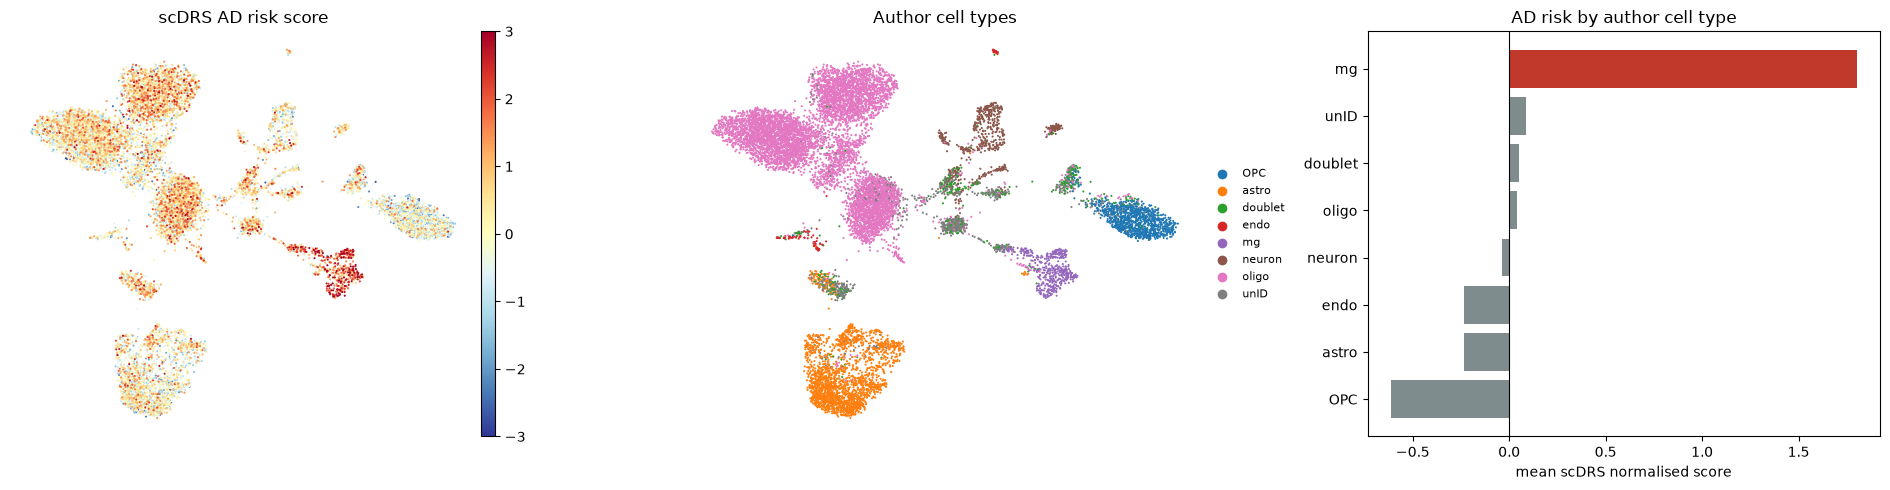

In [6]:
adata.obs["scdrs_norm_score"] = slim["norm_score"]
adata.obs["scdrs_fdr"] = slim["fdr"]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sc.pl.umap(adata, color="scdrs_norm_score", ax=axes[0], show=False, frameon=False,
           title="scDRS AD risk score", cmap="RdYlBu_r", vmin=-3, vmax=3)
sc.pl.umap(adata, color="oupSample.cellType", ax=axes[1], show=False, frameon=False,
           title="Author cell types", legend_fontsize=8)

by_type = (adata.obs.groupby("oupSample.cellType", observed=True)["scdrs_norm_score"]
                    .mean().sort_values())
axes[2].barh(by_type.index.astype(str), by_type.to_numpy(),
             color=["#c0392b" if t == "mg" else "#7f8c8d" for t in by_type.index])
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set(xlabel="mean scDRS normalised score", title="AD risk by author cell type")

plt.tight_layout()
save_fig(fig, "06_scdrs_overview")
plt.show()